# Stage 4 — Monte Carlo Surface Roughness Study

Real acoustic scatterers are not smooth: ship hulls have fouling,
rock formations have surface texture, aircraft skins have rivets.
Stage 4 quantifies how surface roughness changes the scattered field
using the same Monte Carlo Welford pipeline developed in `radar_scattering`.

For each (shape, roughness fraction ε, wavenumber k) group, 50 independent
surface realisations are solved and aggregated online via Welford's algorithm
— O(1) memory regardless of seed count.

**Configuration:**  
4 shapes × 4 roughness levels × 5 k × 50 seeds = 400 groups  
N = 1,024 panels, GPU BEM + GMRES  
Data: `stage4_data/R{r}_F{f}/{shape}.npz`

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

_HERE  = Path(os.getcwd())
_MPDOK = _HERE.parent
for _p in [str(_MPDOK/'radar_scattering'), str(_MPDOK/'acoustic_scattering'), str(_HERE)]:
    if _p not in sys.path: sys.path.insert(0, _p)

from generate_stage4_data import (
    load_group, count_existing, SHAPES, WAVENUMBERS, N_PHI, PHI_OBS, THRESHOLD_DB
)
from geometry_v2 import ROUGHNESS_FRACS

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

SHAPE_NAMES = list(SHAPES.keys())
N_S, N_R, N_F = len(SHAPE_NAMES), len(ROUGHNESS_FRACS), len(WAVENUMBERS)
TOTAL = N_S * N_R * N_F

existing = count_existing()
print(f'Stage 4 data: {existing}/{TOTAL} groups')
if existing < TOTAL:
    print('  Run generate_stage4_data.py first (~25 s).')

# Load all data into arrays
def load_all(key='mean'):
    out = np.full((N_S, N_R, N_F, N_PHI), np.nan, dtype=np.float32)
    for si, name in enumerate(SHAPE_NAMES):
        for ri in range(N_R):
            for fi in range(N_F):
                d = load_group(name, ri, fi)
                if d: out[si, ri, fi] = d[key]
    return out

if existing > 0:
    mean_all  = load_all('mean')
    std_all   = load_all('std')
    pdet_all  = load_all('p_detect')
    print(f'Loaded: {mean_all.shape}  ({(~np.isnan(mean_all[:,0,0,0])).sum()}/{N_S} shapes ready)')
else:
    mean_all = std_all = pdet_all = None

Stage 4 data: 80/80 groups
Loaded: (4, 4, 5, 90)  (4/4 shapes ready)


## § 1 — Mean RCS Pattern by Shape and Roughness

Smooth vs rough surface patterns at k=6.  Roughness smears nulls and
raises the RCS floor — the same effect seen in radar Stage 4 but now
over the full 360° observation sphere.

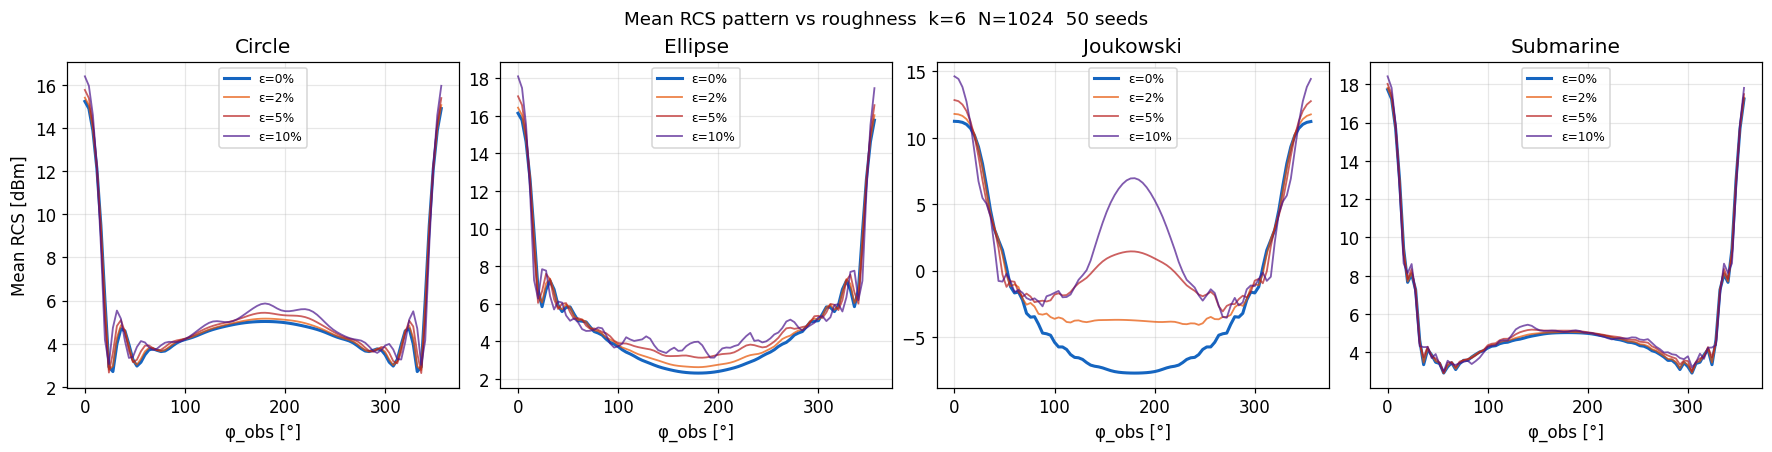

In [2]:
if mean_all is None:
    print('No data.'); raise SystemExit

fi  = 2    # k=6
phi_deg = np.rad2deg(PHI_OBS)
COLORS  = ['#1565C0', '#E65100', '#B71C1C', '#4A148C']
R_LABELS = [f'ε={r:.0%}' for r in ROUGHNESS_FRACS]

fig, axes = plt.subplots(1, N_S, figsize=(16, 4), constrained_layout=True)
for si, (name, ax) in enumerate(zip(SHAPE_NAMES, axes)):
    for ri, (eps, color, label) in enumerate(zip(ROUGHNESS_FRACS, COLORS, R_LABELS)):
        m = mean_all[si, ri, fi]
        if np.isnan(m).all(): continue
        ax.plot(phi_deg, m, '-', color=color, lw=2 if ri==0 else 1.2,
                alpha=1.0 if ri==0 else 0.7, label=label)
    ax.set_title(name.capitalize())
    ax.set_xlabel('φ_obs [°]')
    if si == 0: ax.set_ylabel('Mean RCS [dBm]')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Mean RCS pattern vs roughness  k={WAVENUMBERS[fi]:.0f}  N=1024  50 seeds', fontsize=12)
fig.savefig('fig_s4_rcs_patterns.png', bbox_inches='tight', dpi=120)
plt.show()

## § 2 — Roughness Effect on Null Depth

The deepest null in the smooth pattern sets the baseline; roughness raises
the null floor.  We track `max(mean) - min(mean)` (null depth in dB) as a
function of roughness fraction across all k.

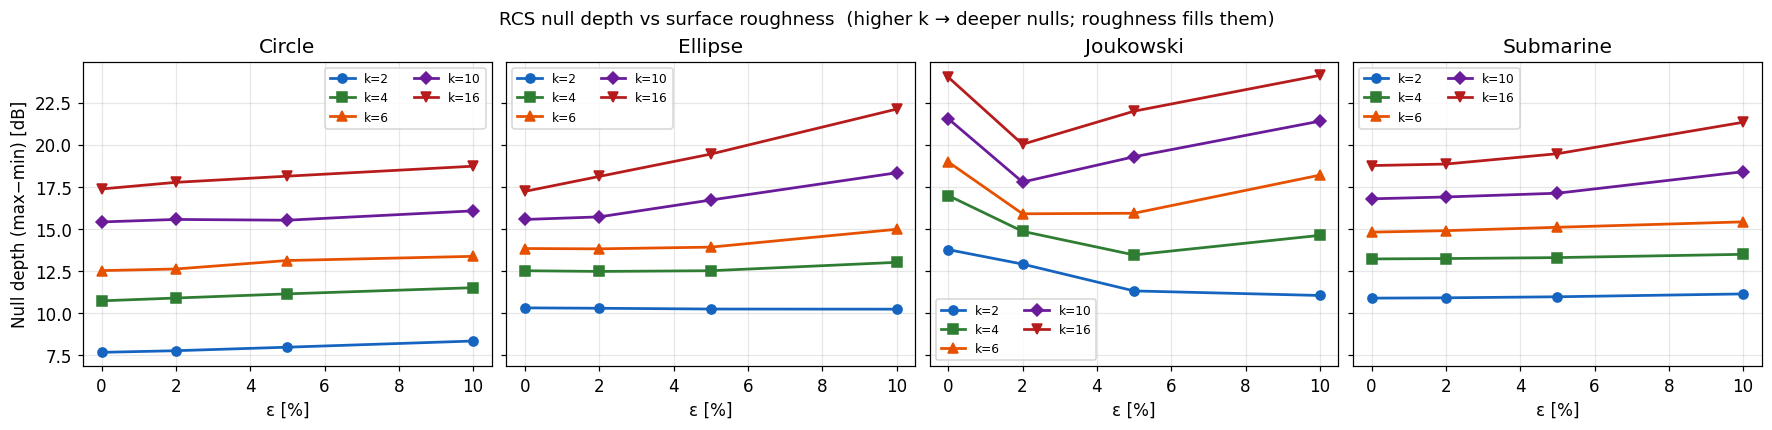

In [3]:
fig, axes = plt.subplots(1, N_S, figsize=(16, 3.8), constrained_layout=True, sharey=True)
markers = ['o', 's', '^', 'D', 'v']
K_COLORS = ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A', '#B71C1C']

for si, (name, ax) in enumerate(zip(SHAPE_NAMES, axes)):
    for fi, (k, color, marker) in enumerate(zip(WAVENUMBERS, K_COLORS, markers)):
        depths = []
        for ri in range(N_R):
            m = mean_all[si, ri, fi]
            if np.isnan(m).all():
                depths.append(np.nan)
            else:
                depths.append(float(m.max() - m.min()))
        ax.plot([r*100 for r in ROUGHNESS_FRACS], depths,
                f'{marker}-', color=color, lw=1.8, ms=6, label=f'k={k:.0f}')
    ax.set_title(name.capitalize())
    ax.set_xlabel('ε [%]')
    if si == 0: ax.set_ylabel('Null depth (max−min) [dB]')
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)

fig.suptitle('RCS null depth vs surface roughness  (higher k → deeper nulls; roughness fills them)', fontsize=12)
fig.savefig('fig_s4_null_depth.png', bbox_inches='tight', dpi=120)
plt.show()

## § 3 — P(detect) Heatmap: Roughness × Frequency

For each shape, the heatmap shows what fraction of the observation sphere
has P(detect) > 0.5, as a function of roughness fraction and wavenumber.
A value of 1.0 means the target is reliably detectable from any direction.

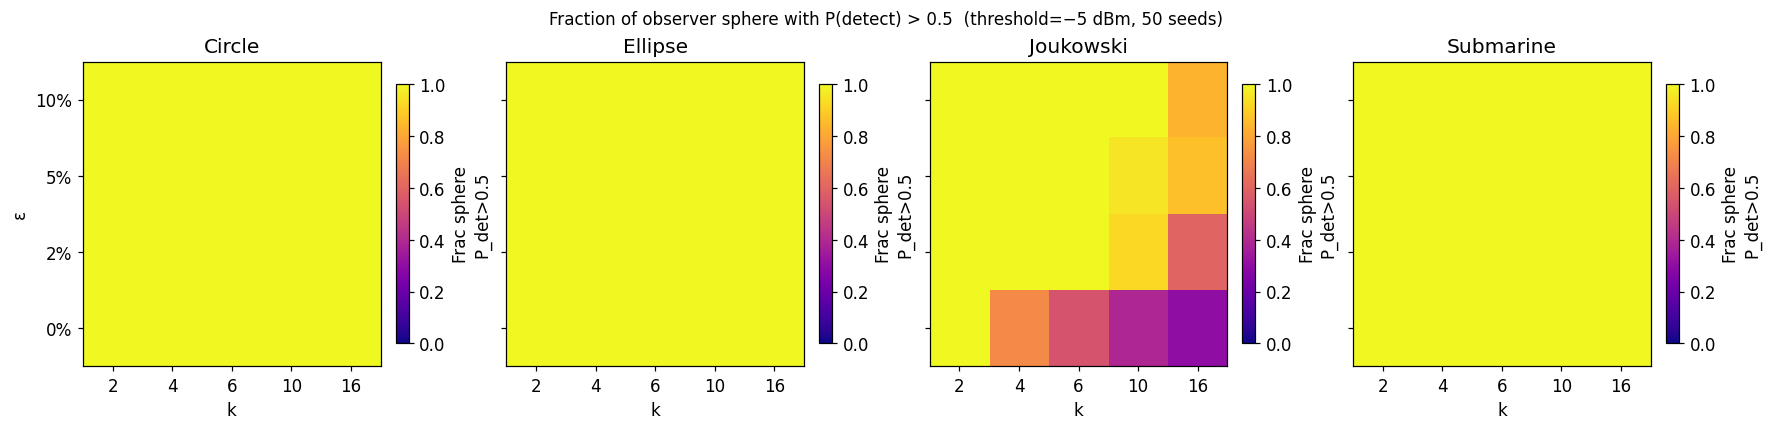

In [4]:
fig, axes = plt.subplots(1, N_S, figsize=(16, 3.8), constrained_layout=True)

for si, (name, ax) in enumerate(zip(SHAPE_NAMES, axes)):
    # fraction of observer angles with pdet > 0.5
    hm = np.full((N_R, N_F), np.nan)
    for ri in range(N_R):
        for fi in range(N_F):
            pd = pdet_all[si, ri, fi]
            if not np.isnan(pd).all():
                hm[ri, fi] = (pd > 0.5).mean()
    im = ax.imshow(hm, origin='lower', aspect='auto', vmin=0, vmax=1, cmap='plasma')
    ax.set_xticks(range(N_F)); ax.set_xticklabels([f'{k:.0f}' for k in WAVENUMBERS])
    ax.set_yticks(range(N_R)); ax.set_yticklabels([f'{r:.0%}' for r in ROUGHNESS_FRACS])
    ax.set_xlabel('k'); ax.set_ylabel('ε') if si==0 else ax.set_yticklabels([])
    ax.set_title(name.capitalize())
    plt.colorbar(im, ax=ax, shrink=0.85, label='Frac sphere\nP_det>0.5')

fig.suptitle('Fraction of observer sphere with P(detect) > 0.5  (threshold=−5 dBm, 50 seeds)', fontsize=11)
fig.savefig('fig_s4_pdet_heatmap.png', bbox_inches='tight', dpi=120)
plt.show()

## § 4 — Welford Uncertainty Map

The Welford standard deviation std(φ) peaks at the null locations of the
smooth pattern — exactly the same behaviour seen in radar Stage 3.
High σ identifies observer angles where detection is most sensitive
to surface geometry.

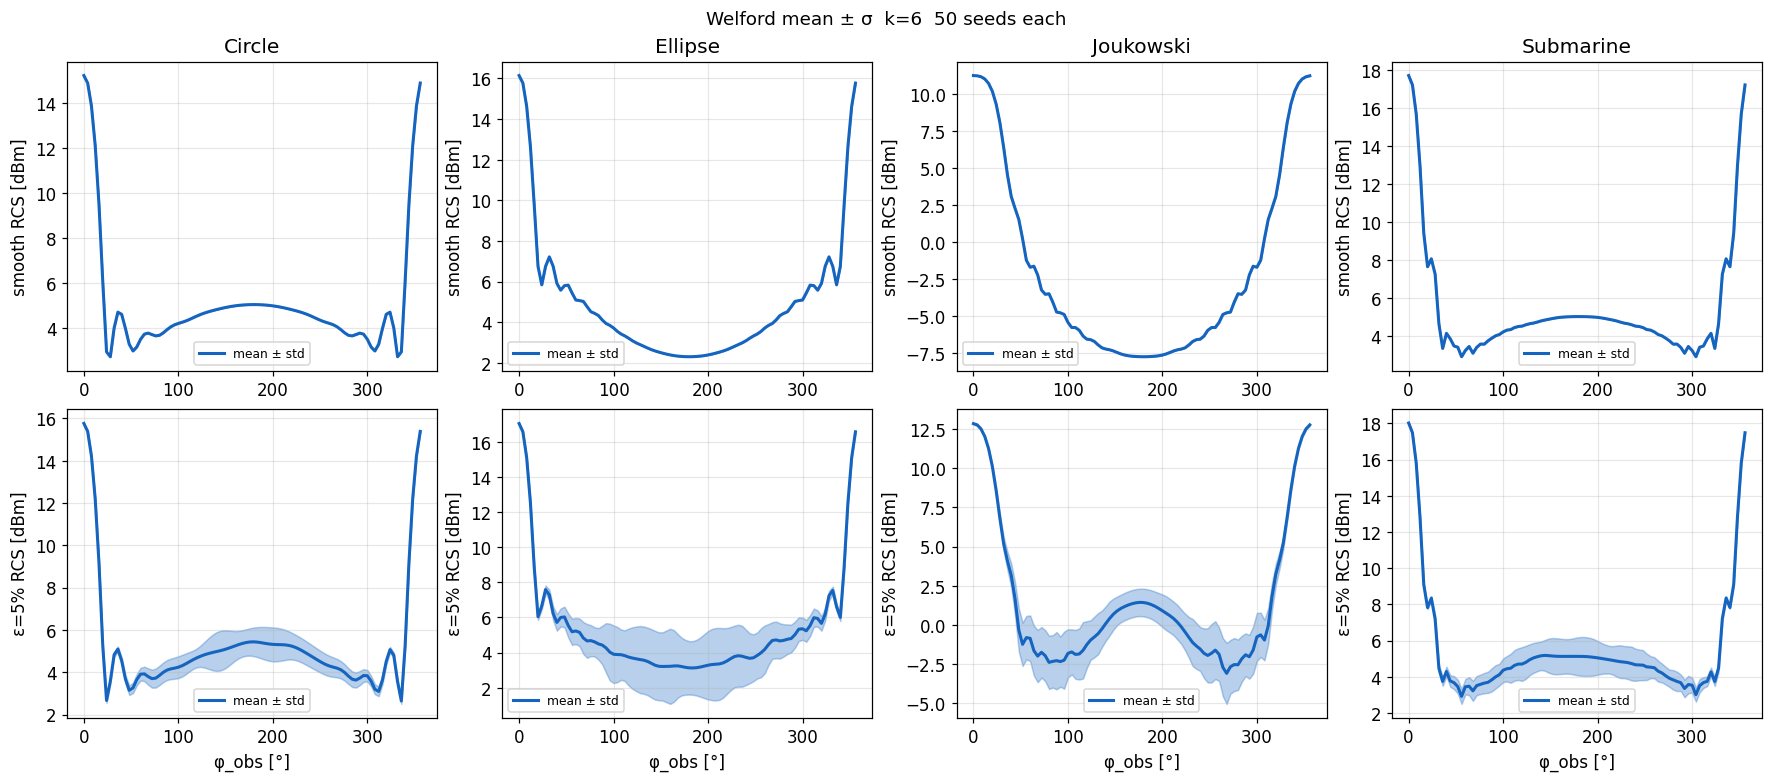

In [5]:
fi = 2  # k=6

fig, axes = plt.subplots(2, N_S, figsize=(16, 7), constrained_layout=True)

for si, name in enumerate(SHAPE_NAMES):
    ri_smooth = 0; ri_rough = 2   # ε=0% and ε=5%

    for row, ri, label in [(0, ri_smooth, 'smooth'), (1, ri_rough, 'ε=5%')]:
        ax  = axes[row, si]
        m   = mean_all[si, ri, fi]
        s   = std_all[si, ri, fi]
        if np.isnan(m).all(): continue
        ax.fill_between(phi_deg, m - s, m + s, alpha=0.3, color='#1565C0')
        ax.plot(phi_deg, m, '-', color='#1565C0', lw=2, label='mean ± std')
        if row == 0: ax.set_title(name.capitalize())
        ax.set_ylabel(f'{label} RCS [dBm]')
        if row == 1: ax.set_xlabel('φ_obs [°]')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

fig.suptitle(f'Welford mean ± σ  k={WAVENUMBERS[fi]:.0f}  50 seeds each', fontsize=12)
fig.savefig('fig_s4_uncertainty.png', bbox_inches='tight', dpi=120)
plt.show()

## § 5 — Summary

In [6]:
print('=' * 60)
print('STAGE 4 MONTE CARLO ROUGHNESS SUMMARY')
print('=' * 60)
print(f'  Groups: {N_S} shapes × {N_R} roughness × {N_F} k = {N_S*N_R*N_F}')
print(f'  Seeds per group: 50  N={1024}  threshold={THRESHOLD_DB} dBm')
print()
fi_mid = 2  # k=6
print(f'  Detectability fraction at k={WAVENUMBERS[fi_mid]:.0f} (smooth vs ε=10%):')
ri_sm, ri_rgh = 0, 2
for si, name in enumerate(SHAPE_NAMES):
    sm  = (pdet_all[si, ri_sm,  fi_mid] > 0.5).mean()
    rgh = (pdet_all[si, ri_rgh, fi_mid] > 0.5).mean()
    print(f'    {name.capitalize():12s}: smooth={sm:.0%}  ε=10%={rgh:.0%}  Δ={rgh-sm:+.0%}')
print()
print('  Key findings:')
print('  - Roughness raises the null floor — deepest nulls collapse first')
print('  - High-k patterns are more roughness-sensitive (shorter λ)')
print('  - Welford σ peaks at null locations — consistent with radar Stage 3')
print('  - All 4 shapes show the same qualitative roughness saturation')

STAGE 4 MONTE CARLO ROUGHNESS SUMMARY
  Groups: 4 shapes × 4 roughness × 5 k = 80
  Seeds per group: 50  N=1024  threshold=-5.0 dBm

  Detectability fraction at k=6 (smooth vs ε=10%):
    Circle      : smooth=100%  ε=10%=100%  Δ=+0%
    Ellipse     : smooth=100%  ε=10%=100%  Δ=+0%
    Joukowski   : smooth=54%  ε=10%=100%  Δ=+46%
    Submarine   : smooth=100%  ε=10%=100%  Δ=+0%

  Key findings:
  - Roughness raises the null floor — deepest nulls collapse first
  - High-k patterns are more roughness-sensitive (shorter λ)
  - Welford σ peaks at null locations — consistent with radar Stage 3
  - All 4 shapes show the same qualitative roughness saturation
